# Car-Wash Local Markets: Entry Effects, Ramp-Up & Cluster-Level MOIRAI Forecasting

**Data:** `../data/main-ds.csv` — monthly operational metrics for ~2,000 car-wash sites, Jan 2020 → Jun 2026.
A **unique site = (`client_id`, `site_id`)**. Each site's series begins at its `operational_start`.

**Goal — find learnable relationships about:**
1. How a **new site opening** impacts neighbouring existing sites (cannibalization).
2. How **new sites ramp up** after opening.
3. Common trends across **local markets** (DBSCAN clusters, 20 km).

**Pipeline**
- **§1** Load & clean · **§2** DBSCAN (20 km) → local markets · **§3** Entry events · **§4** Event study (impact on incumbents) ·
  **§5** New-site ramp-up · **§6** Within-cluster co-movement · **§7** **Cluster-level MOIRAI** (zero-shot forecast, *counterfactual* entry impact, neighbour covariates, ramp-up forecast) · **§8** Synthesis.

> **Note on environment.** §1–§6 run in the main kernel (numpy/sklearn/scipy).
> MOIRAI (uni2ts) pins old torch/numpy and is installed in an **isolated venv** (`../.venv-moirai`); its heavy compute is run once by
> `moirai_experiments.py` and **cached to `artifacts/`**, which §7 just loads & plots. All time-series modelling is done **per-cluster**, never on a single global pool.

## 0. Setup

In [1]:
import os, json, warnings, subprocess, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize':(11,4.5), 'figure.dpi':110, 'axes.grid':True})

DATA = Path('../data/main-ds.csv')
ART  = Path('artifacts'); ART.mkdir(exist_ok=True)
FIG  = Path('figures');   FIG.mkdir(exist_ok=True)
RADIUS_KM, EARTH_KM = 20.0, 6371.0088
VENV_MOIRAI = Path('../.venv-moirai/bin/python')   # isolated env for uni2ts

def haversine_km(lat1, lon1, lat2, lon2):
    r = np.radians; lat1,lon1,lat2,lon2 = map(r,[lat1,lon1,lat2,lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 2*EARTH_KM*np.arcsin(np.sqrt(np.clip(a,0,1)))
print('setup ok | MOIRAI env present:', VENV_MOIRAI.exists())

setup ok | MOIRAI env present: True


## 1. Load & clean

- Parse the monthly date and `operational_start` (always equals each site's first observed month → series start = opening).
- Build `site_key = client_id::site_id`.
- **Clean revenue outliers:** implied ASP (`revenue/wash_count`) above \$200 is implausible for a car wash (data errors with tiny counts); null those revenue cells. Wash **counts** are left untouched — they are the cleanest signal.
- Derive `tot_wash_count`, `tot_revenue`, `mem_share_wash`.

In [2]:
raw = pd.read_csv(DATA, low_memory=False)
raw['date']     = pd.to_datetime(dict(year=raw.year, month=raw.month, day=1))
raw['op_start'] = pd.to_datetime(raw['operational_start'], format='%m-%Y', errors='coerce')
raw['site_key'] = raw.client_id.astype(str) + '::' + raw.site_id.astype(str)

df = raw.copy()
df['ASP_ret_calc'] = np.where(df.ret_wash_count>0, df.ret_revenue/df.ret_wash_count, np.nan)
df['ASP_mem_calc'] = np.where(df.mem_wash_count>0, df.mem_revenue/df.mem_wash_count, np.nan)
bad_ret, bad_mem = df.ASP_ret_calc>200, df.ASP_mem_calc>200
df.loc[bad_ret, ['ret_revenue','ASP_ret_calc']] = np.nan
df.loc[bad_mem, ['mem_revenue','ASP_mem_calc']] = np.nan
df['tot_wash_count'] = df.mem_wash_count + df.ret_wash_count
df['tot_revenue']    = df[['mem_revenue','ret_revenue']].sum(axis=1, min_count=1)
df['mem_share_wash'] = np.where(df.tot_wash_count>0, df.mem_wash_count/df.tot_wash_count, np.nan)

print(f'rows={len(df):,} | {df.date.min():%Y-%m} -> {df.date.max():%Y-%m} ({df.date.nunique()} months) | sites={df.site_key.nunique():,}')
print(f'revenue cells nulled as implausible: retail={bad_ret.sum()}, membership={bad_mem.sum()}')
df.head(3)

rows=67,251 | 2020-01 -> 2026-06 (78 months) | sites=2,022
revenue cells nulled as implausible: retail=394, membership=131


,client_name,client_id,site_id,year,month,mem_purchase_count,mem_wash_count,mem_revenue,ret_wash_count,ret_revenue,...,lon,operational_start,date,op_start,site_key,ASP_ret_calc,ASP_mem_calc,tot_wash_count,tot_revenue,mem_share_wash
0,Hurricane Bay Express,000003_hurricane,1,2020,1,0,0,0.0,1699,23442.0,...,-85.518525,01-2020,2020-01-01,2020-01-01,000003_hurricane::1,13.797528,NaN,1699,23442.0,0.0
1,Hurricane Bay Express,000003_hurricane,1,2020,2,0,0,0.0,2895,40824.0,...,-85.518525,01-2020,2020-02-01,2020-01-01,000003_hurricane::1,14.101554,NaN,2895,40824.0,0.0
2,Hurricane Bay Express,000003_hurricane,1,2020,3,0,0,0.0,2438,34418.0,...,-85.518525,01-2020,2020-03-01,2020-01-01,000003_hurricane::1,14.117309,NaN,2438,34418.0,0.0


sites=2,022 | with coords=1,947 | left-censored (open <=2020-01, treated as mature incumbents only)=322 | genuinely-observed openings=1700


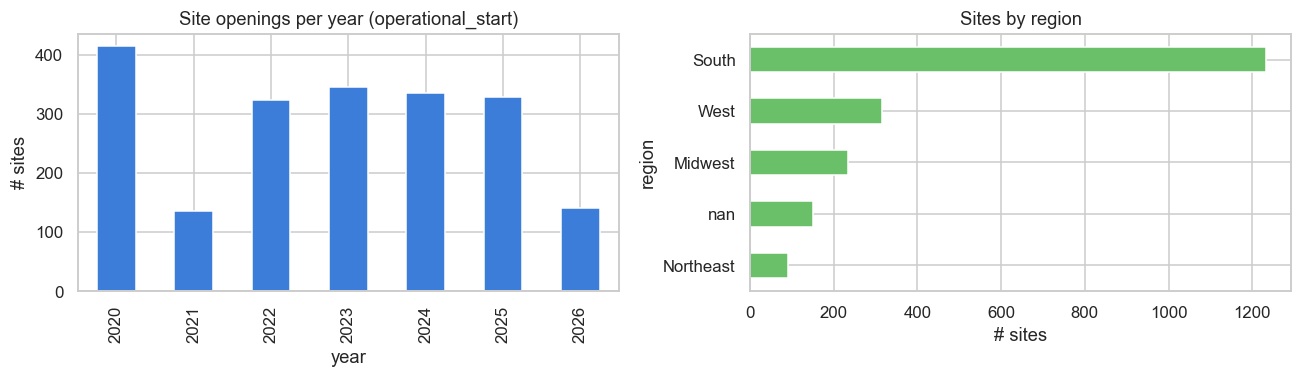

In [3]:
# Site metadata table
site = df.groupby('site_key').agg(
    client_id=('client_id','first'), client_name=('client_name','first'), site_id=('site_id','first'),
    lat=('lat','first'), lon=('lon','first'), state=('state','first'), region=('region','first'),
    op_start=('op_start','first'), first_obs=('date','min'), last_obs=('date','max'), n_obs=('date','size')
).reset_index()
site['span']         = (site.last_obs.dt.year-site.first_obs.dt.year)*12 + (site.last_obs.dt.month-site.first_obs.dt.month) + 1
site['has_gap']      = site.n_obs < site.span
site['left_censored']= site.op_start <= pd.Timestamp('2020-01-01')   # already operating at the data-window start
site['has_coords']   = site[['lat','lon']].notna().all(axis=1)
print(f'sites={len(site):,} | with coords={site.has_coords.sum():,} | '
      f'left-censored (open <=2020-01, treated as mature incumbents only)={site.left_censored.sum()} | '
      f'genuinely-observed openings={ (~site.left_censored).sum() }')

fig, ax = plt.subplots(1,2, figsize=(12,3.6))
site.op_start.dt.year.value_counts().sort_index().plot.bar(ax=ax[0], color='#3b7dd8')
ax[0].set(title='Site openings per year (operational_start)', xlabel='year', ylabel='# sites')
site.groupby('region', dropna=False).size().sort_values().plot.barh(ax=ax[1], color='#6abf69')
ax[1].set(title='Sites by region', xlabel='# sites')
plt.tight_layout(); plt.savefig(FIG/'01_overview.png', bbox_inches='tight'); plt.show()

## 2. DBSCAN clustering (20 km) → local markets

Cluster sites by location with **DBSCAN**, haversine metric, `eps = 20 km / R_earth`, `min_samples=2`.
A cluster (label ≥ 0) is a **multi-site local market**; label `-1` = standalone site (its own market).

> **Caveat (chaining).** DBSCAN links any two sites within 20 km *transitively*, so a string of sites can merge into one large, geographically wide cluster. We therefore (a) report cluster **diameters** as a diagnostic, and (b) for all *neighbour-level* analyses below use the **direct ≤20 km pairwise graph** (two sites are neighbours iff within 20 km) rather than whole-cluster membership. This keeps "impact on a neighbour" measured on genuine neighbours.

In [4]:
from sklearn.cluster import DBSCAN
geo = site[site.has_coords].copy()
db = DBSCAN(eps=RADIUS_KM/EARTH_KM, min_samples=2, metric='haversine').fit(np.radians(geo[['lat','lon']].values))
geo['cluster'] = db.labels_
site = site.merge(geo[['site_key','cluster']], on='site_key', how='left')
site['cluster'] = site['cluster'].fillna(-1).astype(int)

multi = geo[geo.cluster>=0]
sizes = multi.groupby('cluster').size()
def cluster_diam(g):
    if len(g)<2: return 0.0
    r=np.radians(g[['lat','lon']].values); lat=r[:,:1]; lon=r[:,1:]
    a=np.sin((lat-lat.T)/2)**2+np.cos(lat)*np.cos(lat.T)*np.sin((lon-lon.T)/2)**2
    return float((2*EARTH_KM*np.arcsin(np.sqrt(np.clip(a,0,1)))).max())
diam = multi.groupby('cluster').apply(cluster_diam, include_groups=False)
print(f'multi-site clusters={sizes.size} | sites in clusters={int((geo.cluster>=0).sum())} | standalone={int((geo.cluster==-1).sum())}')
print(f'cluster size: median={sizes.median():.0f} mean={sizes.mean():.1f} max={sizes.max()}')
print(f'cluster diameter km: median={diam.median():.1f} p90={diam.quantile(.9):.1f} max={diam.max():.1f} | chained(>60km)={int((diam>60).sum())}')

# persist artifacts consumed by moirai_experiments.py
df.to_parquet(ART/'panel.parquet'); site.to_parquet(ART/'site.parquet')

multi-site clusters=235 | sites in clusters=1590 | standalone=357
cluster size: median=3 mean=6.8 max=98
cluster diameter km: median=13.4 p90=49.7 max=137.9 | chained(>60km)=19


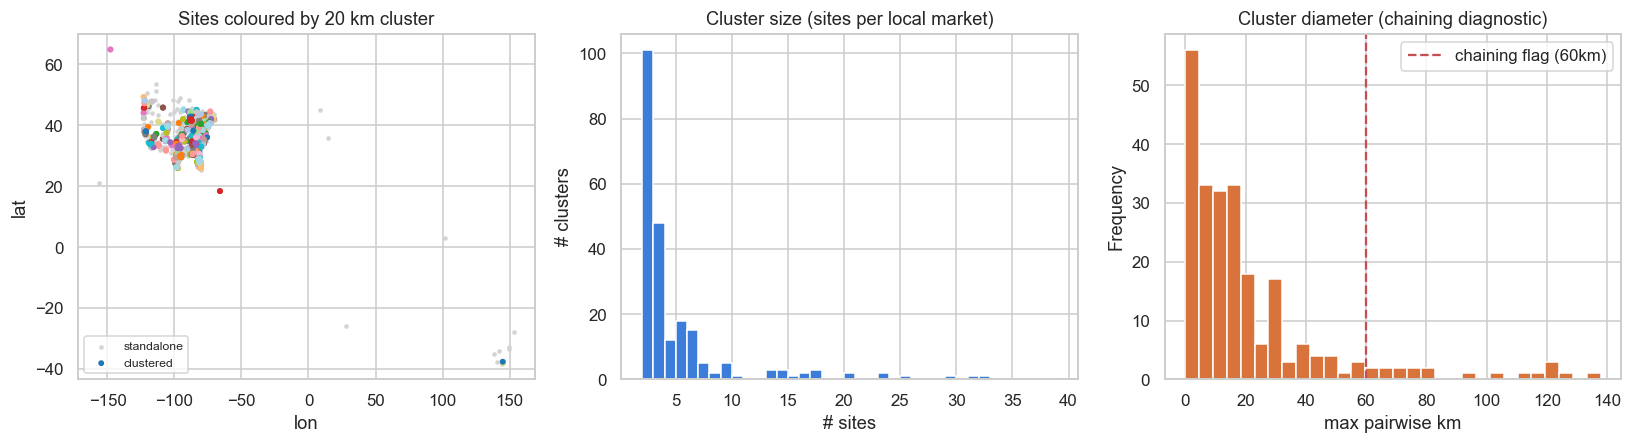

In [5]:
fig, ax = plt.subplots(1,3, figsize=(15,4.2))
# (a) map
noise = geo[geo.cluster==-1]
ax[0].scatter(noise.lon, noise.lat, s=4, c='lightgray', label='standalone')
ax[0].scatter(multi.lon, multi.lat, s=8, c=(multi.cluster*97%20), cmap='tab20', label='clustered')
ax[0].set(title='Sites coloured by 20 km cluster', xlabel='lon', ylabel='lat'); ax[0].legend(loc='lower left', fontsize=8)
# (b) size dist
sizes.plot.hist(bins=range(2,40), ax=ax[1], color='#3b7dd8')
ax[1].set(title='Cluster size (sites per local market)', xlabel='# sites', ylabel='# clusters')
# (c) diameter
diam.plot.hist(bins=30, ax=ax[2], color='#d8743b'); ax[2].axvline(60, c='r', ls='--', label='chaining flag (60km)')
ax[2].set(title='Cluster diameter (chaining diagnostic)', xlabel='max pairwise km'); ax[2].legend()
plt.tight_layout(); plt.savefig(FIG/'02_clusters.png', bbox_inches='tight'); plt.show()

> **Update — adaptive clustering adopted (better than this fixed 20 km).** A **density-aware** scheme — a site links to a neighbour only within `min(rᵢ, rⱼ)`, where rᵢ = **10 km if dense (≥5 sites within 10 km) else 20 km**; components wider than 25 km are re-split; isolated sites are standalone — was **baked off** against this fixed-20 km DBSCAN and HDBSCAN in [`coldstart_forecast.ipynb`](coldstart_forecast.ipynb) §1. **It wins:** same coverage (~80%), but **higher within-cluster co-movement** (all-pairs r **0.59 vs 0.52**), **bounded diameters** (p90 **21 km vs 50 km** — no chaining), and **finer markets** (387 vs 235). It is the strategy used by the Streamlit app and the cold-start forecaster (`coldstart_model.assign_clusters`). The MOIRAI analyses below are **unaffected**: they define neighbours via the **direct ≤20 km pairwise graph** (clustering-independent), so the cannibalization gradient and counterfactuals hold under either scheme.

## 3. New-site entry events

An **entry event** = a *genuinely-observed* opening (entrant `op_start ≥ 2020-02`, i.e. not left-censored) that joins a cluster where ≥1 **incumbent** was already operating ≥4 months earlier. We record every (entrant, incumbent) pair and the haversine distance between them, so impact can be sliced by proximity.

entrant openings with incumbents=1152 | (entrant,incumbent) pairs=20,035 | clusters touched=207
pair distance km: median=34.4 | within 20km=5,247 pairs


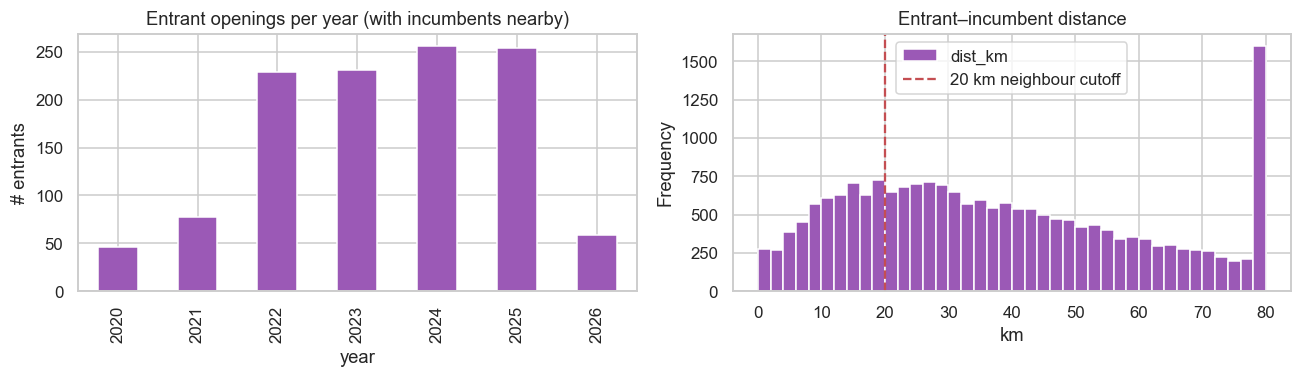

In [6]:
PRE_MIN = 4
rows = []
for c, g in site[site.cluster>=0].groupby('cluster'):
    g = g.sort_values('op_start')
    for _, e in g.iterrows():
        T = e.op_start
        if pd.isna(T) or T <= pd.Timestamp('2020-01-01'):   # entrant must be a real observed opening
            continue
        inc = g[(g.op_start <= T - pd.DateOffset(months=PRE_MIN)) & (g.site_key != e.site_key)]
        for _, i in inc.iterrows():
            rows.append(dict(cluster=c, entry_date=T, entrant=e.site_key, incumbent=i.site_key,
                             dist_km=haversine_km(e.lat,e.lon,i.lat,i.lon),
                             inc_left_cens=bool(i.left_censored)))
ev = pd.DataFrame(rows)
ev.to_parquet(ART/'events.parquet')
print(f'entrant openings with incumbents={ev.entrant.nunique()} | (entrant,incumbent) pairs={len(ev):,} | clusters touched={ev.cluster.nunique()}')
print(f'pair distance km: median={ev.dist_km.median():.1f} | within 20km={int((ev.dist_km<=20).sum()):,} pairs')

fig, ax = plt.subplots(1,2, figsize=(12,3.6))
ev.groupby(ev.entry_date.dt.year).entrant.nunique().plot.bar(ax=ax[0], color='#9b59b6')
ax[0].set(title='Entrant openings per year (with incumbents nearby)', xlabel='year', ylabel='# entrants')
ev.dist_km.clip(upper=80).plot.hist(bins=40, ax=ax[1], color='#9b59b6')
ax[1].axvline(20, c='r', ls='--', label='20 km neighbour cutoff'); ax[1].legend()
ax[1].set(title='Entrant–incumbent distance', xlabel='km')
plt.tight_layout(); plt.savefig(FIG/'03_events.png', bbox_inches='tight'); plt.show()

## 4. Event study — what happens to incumbents around an entry

**Method.** For each (incumbent, entry) pair we build the incumbent's metric on **relative time** `k = months since entry` (k=0 = entry month), window `[-12, +18]`.
- **Deseasonalize** each metric by a region×calendar-month multiplicative factor.
- **Normalize** to the incumbent's pre-entry baseline (mean of `k∈[-6,-1]`) → % of baseline.
- Aggregate the **median** trajectory (robust to the heavy right tail) with a percentile-bootstrap 95% band.

**Identification.** Retail washes are falling *market-wide* (secular shift to memberships), which hits every site regardless of distance. So we read cannibalization off the **distance gradient**: the *extra* decline that scales with how close the entrant is.

In [7]:
# Deseasonalize (region x month, multiplicative) and build a per-site indexed panel
d = df.copy(); d['region'] = d['region'].fillna('Unknown'); d['moy'] = d.date.dt.month
METRICS = ['ret_wash_count','mem_wash_count','tot_wash_count','tot_revenue']
for m in METRICS:
    rm = d.groupby(['region','moy'])[m].transform('mean'); rr = d.groupby('region')[m].transform('mean')
    d[m+'_des'] = d[m] / (rm/rr).replace(0, np.nan)
P = d.set_index(['site_key','date']).sort_index()

# Market-wide secular trend (control): median deseasonalized series across all sites, indexed to 2021=100
def market_index(col):
    s = d.groupby('date')[col].median(); return s / s['2021-01-01':'2021-12-01'].mean() * 100
mkt_ret, mkt_mem = market_index('ret_wash_count_des'), market_index('mem_wash_count_des')
print('Market-wide per-site washes, indexed 2021=100:')
for y in range(2020,2026):
    print(f'  {y}:  retail={mkt_ret[f"{y}-01-01":f"{y}-12-01"].mean():5.0f}   membership={mkt_mem[f"{y}-01-01":f"{y}-12-01"].mean():5.0f}')

Market-wide per-site washes, indexed 2021=100:
  2020:  retail=   82   membership=   47
  2021:  retail=  100   membership=  100
  2022:  retail=   94   membership=  146
  2023:  retail=   88   membership=  199
  2024:  retail=   80   membership=  235
  2025:  retail=   76   membership=  268


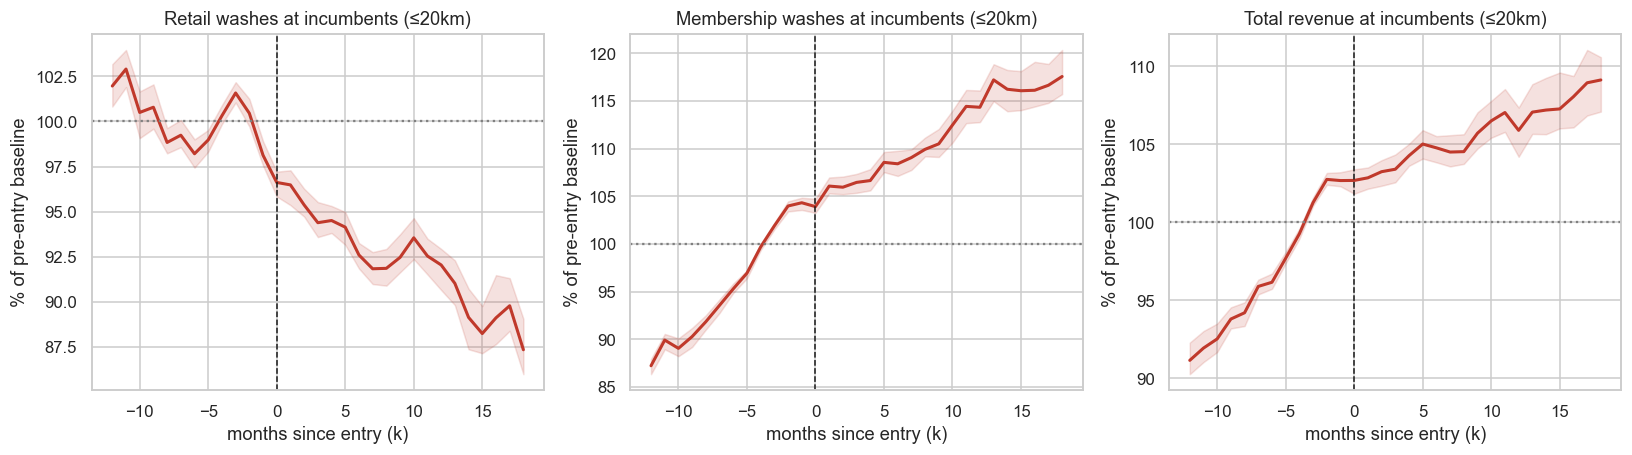

In [8]:
K0, K1 = -12, 18
def rel_series(sk, T, col):
    try: s = P.loc[sk, col]
    except KeyError: return None
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq='MS'))
    k = (s.index.year-T.year)*12 + (s.index.month-T.month)
    o = pd.Series(s.values, index=k); return o[(o.index>=K0)&(o.index<=K1)]

def event_panel(evsub, col):
    rows=[]
    for _, r in evsub.iterrows():
        s = rel_series(r.incumbent, r.entry_date, col)
        if s is None: continue
        base = s[(s.index>=-6)&(s.index<=-1)].mean()
        if not np.isfinite(base) or base<=0: continue
        for k, v in s.items():
            if np.isfinite(v): rows.append((r.incumbent, k, v/base*100))
    es = pd.DataFrame(rows, columns=['inc','k','pct'])
    es['pct'] = es.pct.clip(*es.pct.quantile([.01,.99]))   # winsorize heavy tail
    return es

def boot_median(x, n=200, rng=np.random.default_rng(0)):
    if len(x)<5: return np.nan, np.nan
    bs = [np.median(rng.choice(x, len(x))) for _ in range(n)]
    return np.percentile(bs,2.5), np.percentile(bs,97.5)

near = ev[ev.dist_km<=20]
fig, ax = plt.subplots(1,3, figsize=(15,4.3))
for j,(col,title) in enumerate([('ret_wash_count_des','Retail washes'),
                                ('mem_wash_count_des','Membership washes'),
                                ('tot_revenue_des','Total revenue')]):
    es = event_panel(near, col); g = es.groupby('k').pct
    med = g.median(); ks = med.index.values
    lo  = np.array([boot_median(es[es.k==k].pct.values)[0] for k in ks])
    hi  = np.array([boot_median(es[es.k==k].pct.values)[1] for k in ks])
    ax[j].plot(ks, med.values, color='#c0392b', lw=2)
    ax[j].fill_between(ks, lo, hi, color='#c0392b', alpha=.15)
    ax[j].axhline(100, c='gray', ls=':'); ax[j].axvline(0, c='k', ls='--', lw=1)
    ax[j].set(title=f'{title} at incumbents (≤20km)', xlabel='months since entry (k)', ylabel='% of pre-entry baseline')
plt.tight_layout(); plt.savefig(FIG/'04_eventstudy.png', bbox_inches='tight'); plt.show()

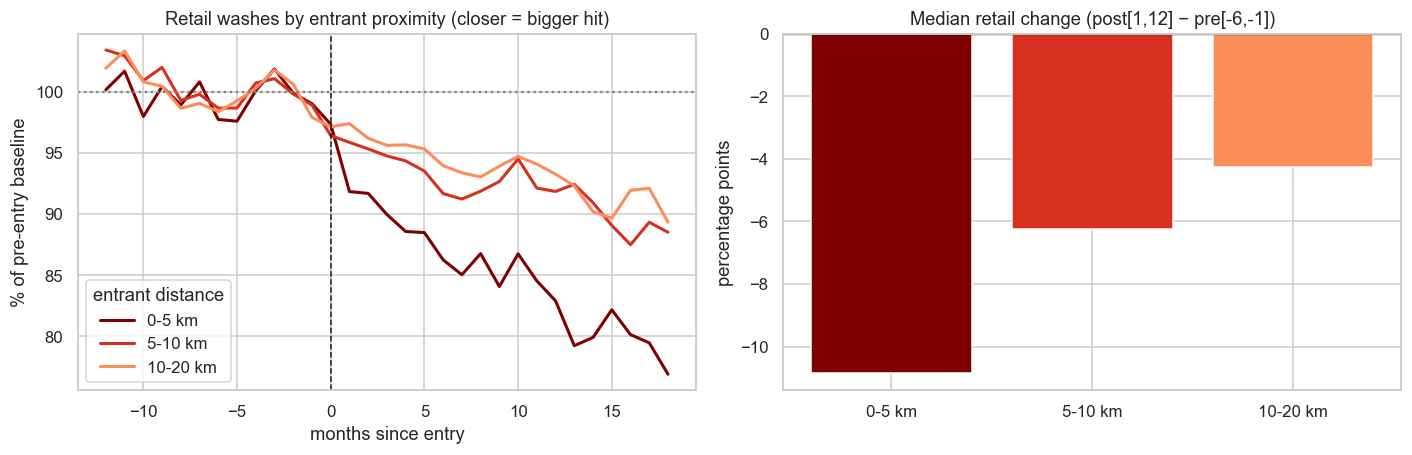

          n_incumbents  median_post_minus_pre_pts  wilcoxon_p
bucket                                                       
0-5 km             353                    -10.859         0.0
5-10 km            506                     -6.229         0.0
10-20 km           787                     -4.244         0.0

Proximity effect: extra retail decline at <5km vs 10-20km = -6.6 pts


In [9]:
# Distance gradient on retail + paired pre/post test
from scipy.stats import wilcoxon
fig, ax = plt.subplots(1,2, figsize=(13,4.3))
summary=[]
for lo,hi,colr in [(0,5,'#7f0000'),(5,10,'#d7301f'),(10,20,'#fc8d59')]:
    es = event_panel(ev[(ev.dist_km>lo)&(ev.dist_km<=hi)], 'ret_wash_count_des')
    med = es.groupby('k').pct.median()
    ax[0].plot(med.index, med.values, lw=2, color=colr, label=f'{lo}-{hi} km')
    pre = es[es.k.between(-6,-1)].groupby('inc').pct.mean(); post = es[es.k.between(1,12)].groupby('inc').pct.mean()
    mm = pd.concat([pre,post],axis=1,keys=['pre','post']).dropna()
    p = wilcoxon(mm.post, mm.pre).pvalue if len(mm)>10 else np.nan
    summary.append((f'{lo}-{hi} km', len(mm), (mm.post-mm.pre).median(), p))
ax[0].axhline(100,c='gray',ls=':'); ax[0].axvline(0,c='k',ls='--',lw=1)
ax[0].set(title='Retail washes by entrant proximity (closer = bigger hit)',
          xlabel='months since entry', ylabel='% of pre-entry baseline'); ax[0].legend(title='entrant distance')
S = pd.DataFrame(summary, columns=['bucket','n_incumbents','median_post_minus_pre_pts','wilcoxon_p']).set_index('bucket')
ax[1].bar(S.index, S.median_post_minus_pre_pts, color=['#7f0000','#d7301f','#fc8d59'])
ax[1].axhline(0,c='k'); ax[1].set(title='Median retail change (post[1,12] − pre[-6,-1])', ylabel='percentage points')
plt.tight_layout(); plt.savefig(FIG/'04b_distance_gradient.png', bbox_inches='tight'); plt.show()
print(S.round(3).to_string())
print('\nProximity effect: extra retail decline at <5km vs 10-20km =',
      round(S.loc["0-5 km","median_post_minus_pre_pts"]-S.loc["10-20 km","median_post_minus_pre_pts"],1), 'pts')

**Read-out.** Retail washes at incumbents drop after a neighbour opens, and the drop **scales with proximity** (≈ −11 pts within 5 km vs −4 pts at 10–20 km). Because the market-wide retail decline is distance-independent, the proximity-scaled *excess* (~6–7 pts) is the cannibalization signal. Membership washes and total revenue keep rising — but, as §7 shows, slower than the no-entry counterfactual.

## 5. New-site ramp-up

For genuinely-observed openings, index each metric by **`m = months since open`**. We report (a) the absolute median trajectory, (b) the membership share curve, and (c) each metric as **% of its own mature level** (mean of months 21–27), with the distribution of **time-to-80%-maturity**.

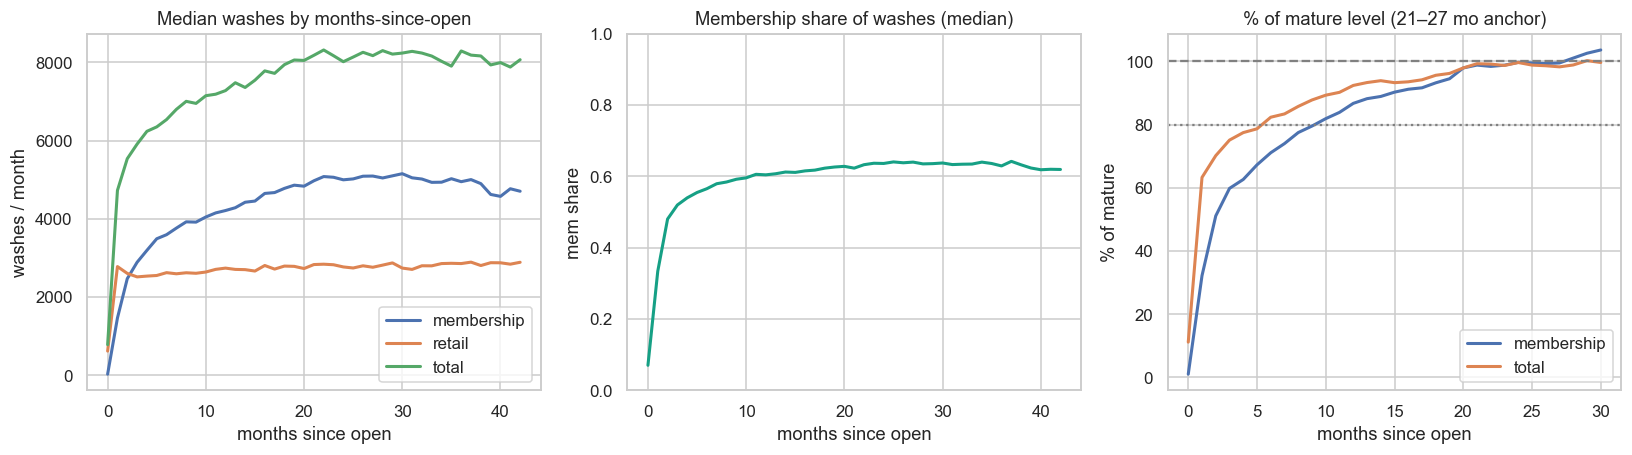

maturity anchor sites (>=24mo): 957
median months for MEMBERSHIP to reach 80% of mature: 7
membership share: open≈0.07 -> month-6≈0.57 -> month-12≈0.60


In [10]:
new_keys = set(site.loc[~site.left_censored, 'site_key'])   # genuinely-observed openings
R = df[df.site_key.isin(new_keys)].copy()                   # df already carries op_start per row
R['m'] = (R.date.dt.year-R.op_start.dt.year)*12 + (R.date.dt.month-R.op_start.dt.month)
R = R[R.m>=0]

ks = [0,1,3,6,9,12,18,24,36]
fig, ax = plt.subplots(1,3, figsize=(15,4.3))
for met,lab in [('mem_wash_count','membership'),('ret_wash_count','retail'),('tot_wash_count','total')]:
    g = R.groupby('m')[met].median()
    ax[0].plot(g.index[g.index<=42], g.values[g.index<=42], lw=2, label=lab)
ax[0].set(title='Median washes by months-since-open', xlabel='months since open', ylabel='washes / month'); ax[0].legend()
gs = R.groupby('m').mem_share_wash.median()
ax[1].plot(gs.index[gs.index<=42], gs.values[gs.index<=42], lw=2, color='#16a085')
ax[1].set(title='Membership share of washes (median)', xlabel='months since open', ylabel='mem share'); ax[1].set_ylim(0,1)

mat = R[R.m.between(21,27)].groupby('site_key').agg(mem_mat=('mem_wash_count','mean'), tot_mat=('tot_wash_count','mean')).reset_index()
mat = mat[(mat.mem_mat>0)&(mat.tot_mat>0)]
Rn = R.merge(mat, on='site_key', how='inner')
for met,matc,lab in [('mem_wash_count','mem_mat','membership'),('tot_wash_count','tot_mat','total')]:
    Rn['r'] = Rn[met]/Rn[matc]*100; g = Rn.groupby('m').r.median()
    ax[2].plot(g.index[g.index<=30], g.values[g.index<=30], lw=2, label=lab)
ax[2].axhline(80, c='gray', ls=':'); ax[2].axhline(100, c='gray', ls='--')
ax[2].set(title='% of mature level (21–27 mo anchor)', xlabel='months since open', ylabel='% of mature'); ax[2].legend()
plt.tight_layout(); plt.savefig(FIG/'05_rampup.png', bbox_inches='tight'); plt.show()

t80 = Rn.assign(r=Rn.mem_wash_count/Rn.mem_mat*100).query('r>=80').groupby('site_key').m.min()
print(f'maturity anchor sites (>=24mo): {Rn.site_key.nunique()}')
print(f'median months for MEMBERSHIP to reach 80% of mature: {t80.median():.0f}')
print(f'membership share: open≈{gs.get(0,np.nan):.2f} -> month-6≈{gs.get(6,np.nan):.2f} -> month-12≈{gs.get(12,np.nan):.2f}')

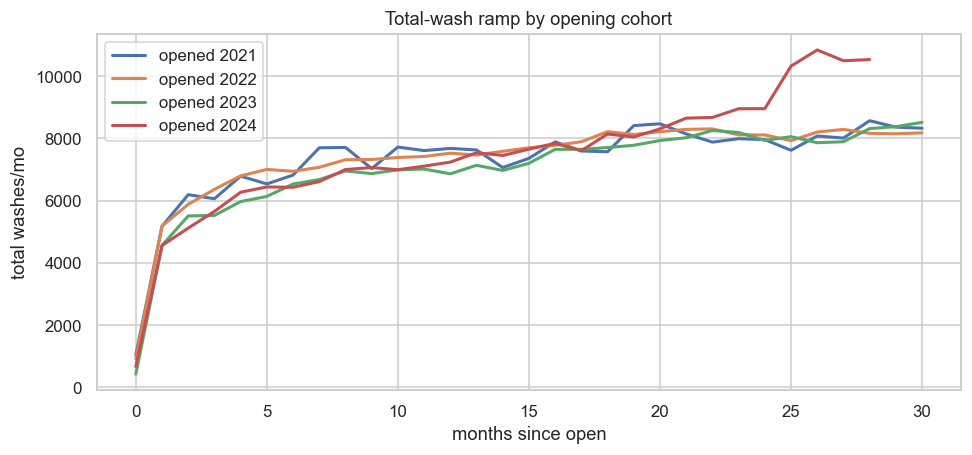

In [11]:
# Cohort view: does ramp shape differ by opening year?
R['cohort'] = R.op_start.dt.year
fig, ax = plt.subplots(figsize=(9,4.3))
for yr in [2021,2022,2023,2024]:
    g = R[R.cohort==yr].groupby('m').tot_wash_count.median()
    ax.plot(g.index[g.index<=30], g.values[g.index<=30], lw=2, label=f'opened {yr}')
ax.set(title='Total-wash ramp by opening cohort', xlabel='months since open', ylabel='total washes/mo'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'05b_cohort.png', bbox_inches='tight'); plt.show()

## 6. Do neighbouring sites move together?

If sites in the same local market share demand shocks, their **deseasonalized** series should correlate more *within* a cluster than between random pairs. This is the statistical basis for cluster-level (multivariate) forecasting in §7.

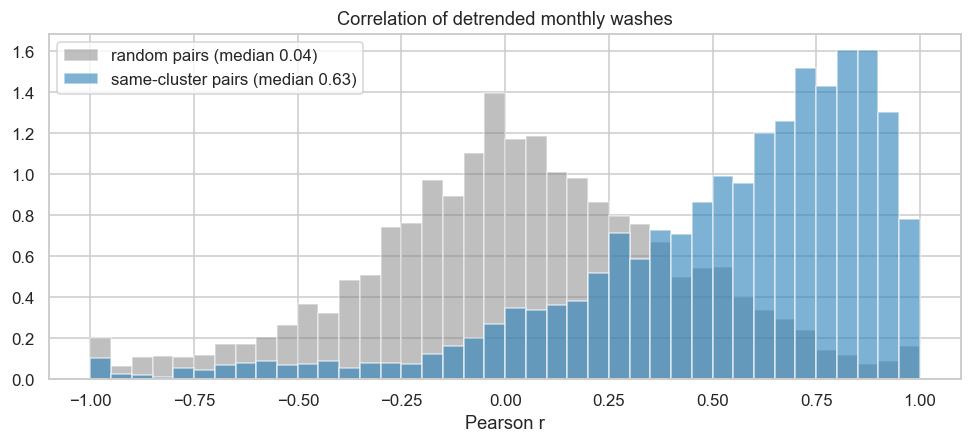

within-cluster median r=0.634 vs random r=0.039 | Mann-Whitney p=0.0e+00


In [12]:
wide = d.pivot_table(index='date', columns='site_key', values='tot_wash_count_des')
def detrend(s):   # remove slow trend, keep month-to-month co-movement
    return s - s.rolling(7, center=True, min_periods=3).mean()
W = wide.apply(detrend)

rng = np.random.default_rng(0)
within=[]; cl_members = site[site.cluster>=0].groupby('cluster').site_key.apply(list)
for members in cl_members:
    members = [m for m in members if m in W.columns]
    for i in range(len(members)):
        for jx in range(i+1, min(i+4, len(members))):
            c = W[members[i]].corr(W[members[jx]])
            if np.isfinite(c): within.append(c)
cols = list(W.columns); across=[]
for _ in range(4000):
    a,b = rng.choice(cols,2,replace=False); c = W[a].corr(W[b])
    if np.isfinite(c): across.append(c)
within, across = np.array(within), np.array(across)
fig, ax = plt.subplots(figsize=(9,4.2))
ax.hist(across, bins=40, density=True, alpha=.5, label=f'random pairs (median {np.median(across):.2f})', color='gray')
ax.hist(within, bins=40, density=True, alpha=.6, label=f'same-cluster pairs (median {np.median(within):.2f})', color='#2980b9')
ax.set(title='Correlation of detrended monthly washes', xlabel='Pearson r'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'06_comovement.png', bbox_inches='tight'); plt.show()
from scipy.stats import mannwhitneyu
print(f'within-cluster median r={np.median(within):.3f} vs random r={np.median(across):.3f} | Mann-Whitney p={mannwhitneyu(within,across,alternative="greater").pvalue:.1e}')

## 7. Cluster-level MOIRAI forecasting

[MOIRAI](https://github.com/SalesforceAIResearch/uni2ts) (Salesforce Uni2TS) is a **zero-shot** probabilistic time-series foundation model. We use `Salesforce/moirai-1.1-R-small`. Everything here is done **per local market / per site within a cluster**, never on one global pooled series.

Four experiments (heavy compute is cached by `moirai_experiments.py` → `artifacts/`):

| # | Experiment | Question |
|---|------------|----------|
| **A** | Zero-shot **backtest** — last 12 months held out (train/test split), actual vs forecast, error by horizon vs a seasonal-naive baseline, interval coverage | **How far off is MOIRAI, and does it beat naive?** |
| **B** | **Counterfactual entry impact** — condition only on an incumbent's *pre-entry* history, forecast 12 mo, compare to actual | Isolates the entry effect against the site's *own* trend+seasonality |
| **C** | **Neighbour covariate** — add co-cluster neighbour mean as a past covariate | Do neighbouring sites carry predictive information? |
| **D** | **Ramp-up forecast** — condition on a new site's first 6 mo, forecast next 12 | Is the ramp curve itself learnable/extrapolable? |

> **B is the key causal-flavoured result:** MOIRAI's pre-entry forecast is the "no-new-competitor" counterfactual; actual − forecast estimates the entrant's impact while controlling for the incumbent's own momentum (which the raw event study cannot).

In [13]:
# (Optional) regenerate MOIRAI artifacts in the isolated env. Off by default — outputs are cached.
RUN_MOIRAI = False
if RUN_MOIRAI and VENV_MOIRAI.exists():
    env = {**os.environ, 'HF_HOME': str(Path('../.venv-moirai/hf_cache').resolve())}
    print(subprocess.run([str(VENV_MOIRAI), 'moirai_experiments.py'], env=env, capture_output=True, text=True).stdout[-2000:])

need = ['mo_backtest.parquet','mo_backtest_examples.json','mo_cf.parquet','mo_cf_examples.json','mo_cov.parquet','mo_ramp.parquet']
missing = [f for f in need if not (ART/f).exists()]
print('cached MOIRAI artifacts present.' if not missing else f'MISSING {missing} -> set RUN_MOIRAI=True (needs {VENV_MOIRAI})')

cached MOIRAI artifacts present.


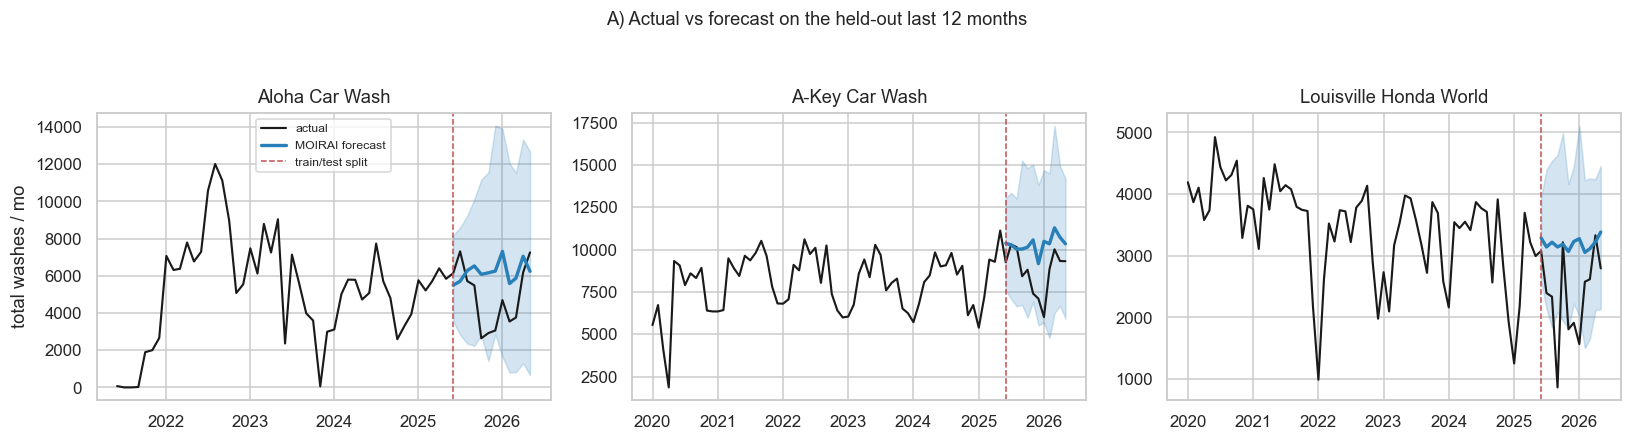

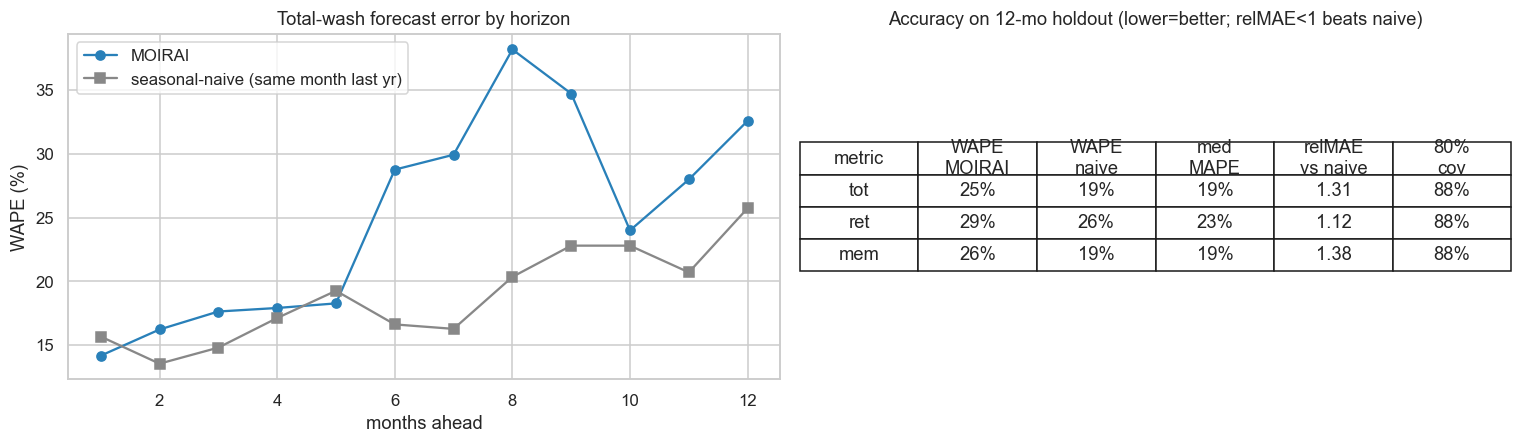

Total washes (n=202 sites, 12-mo holdout): median MAPE=19%  |  WAPE MOIRAI=25% vs seasonal-naive=19%  |  80% interval coverage=88%
Read-out: MOIRAI is well-calibrated and competitive at 1-3 months, but a seasonal-naive baseline edges it at 6-12 months
on these strongly-seasonal, slowly-trending series. MOIRAI earns its keep in regimes naive CANNOT handle:
forecasting from PRE-ENTRY history (B, the counterfactual) and from the FIRST months of a new site (D, the ramp).


In [14]:
# A) Backtest — TRAIN/TEST SPLIT: hold out each site's last 12 months, forecast them, compare to actual.
bt  = pd.read_parquet(ART/'mo_backtest.parquet')
exb = json.load(open(ART/'mo_backtest_examples.json'))
def wape(g, col):  # weighted abs % error — robust to small denominators
    return (g[col]-g.actual).abs().sum() / g.actual.abs().sum() * 100

# (i) actual vs forecast on the held-out window — three example sites
fig, ax = plt.subplots(1, 3, figsize=(15,3.8))
for j,(k,e) in enumerate(list(exb.items())[:3]):
    idx = pd.to_datetime(e['hist_idx']); split = pd.to_datetime(e['split'])
    ax[j].plot(idx, e['hist'], color='k', lw=1.4, label='actual')
    fh = idx[idx>=split][:len(e['fc_median'])]
    ax[j].plot(fh, e['fc_median'], color='#2980b9', lw=2.2, label='MOIRAI forecast')
    ax[j].fill_between(fh, e['fc_p10'], e['fc_p90'], color='#2980b9', alpha=.2)
    ax[j].axvline(split, c='r', ls='--', lw=1, label='train/test split')
    ax[j].set_title(site.loc[site.site_key==k,'client_name'].iloc[0][:24])
    if j==0: ax[j].legend(fontsize=8); ax[j].set_ylabel('total washes / mo')
fig.suptitle('A) Actual vs forecast on the held-out last 12 months', y=1.05, fontsize=12)
plt.tight_layout(); plt.savefig(FIG/'07a_examples.png', bbox_inches='tight'); plt.show()

# (ii) error by horizon vs seasonal-naive baseline  +  (iii) summary table
fig, ax = plt.subplots(1, 2, figsize=(14,4.2))
g = bt[bt.metric=='tot_wash_count']; hz = list(range(1,13))
ax[0].plot(hz, [wape(g[g.h==h],'moirai') for h in hz], '-o', color='#2980b9', label='MOIRAI')
ax[0].plot(hz, [wape(g[g.h==h],'snaive') for h in hz], '-s', color='#888', label='seasonal-naive (same month last yr)')
ax[0].set(title='Total-wash forecast error by horizon', xlabel='months ahead', ylabel='WAPE (%)'); ax[0].legend()
rows=[]
for met in ['tot_wash_count','ret_wash_count','mem_wash_count']:
    gm = bt[bt.metric==met]
    mape = ((gm.moirai-gm.actual).abs()/gm.actual.replace(0,np.nan).abs()).median()*100
    cov  = ((gm.actual>=gm.p10)&(gm.actual<=gm.p90)).mean()*100
    relmae = (gm.moirai-gm.actual).abs().mean()/(gm.snaive-gm.actual).abs().mean()
    rows.append([met.replace('_wash_count',''), f'{wape(gm,"moirai"):.0f}%', f'{wape(gm,"snaive"):.0f}%',
                 f'{mape:.0f}%', f'{relmae:.2f}', f'{cov:.0f}%'])
cols=['metric','WAPE\nMOIRAI','WAPE\nnaive','med\nMAPE','relMAE\nvs naive','80%\ncov']
ax[1].axis('off'); tb=ax[1].table(cellText=rows, colLabels=cols, loc='center', cellLoc='center'); tb.scale(1,1.8)
ax[1].set_title('Accuracy on 12-mo holdout (lower=better; relMAE<1 beats naive)')
plt.tight_layout(); plt.savefig(FIG/'07a_backtest.png', bbox_inches='tight'); plt.show()

gt = bt[bt.metric=='tot_wash_count']
print(f'Total washes (n={gt.site_key.nunique()} sites, 12-mo holdout): median MAPE={((gt.moirai-gt.actual).abs()/gt.actual.replace(0,np.nan).abs()).median()*100:.0f}%  |'
      f'  WAPE MOIRAI={wape(gt,"moirai"):.0f}% vs seasonal-naive={wape(gt,"snaive"):.0f}%  |  80% interval coverage={((gt.actual>=gt.p10)&(gt.actual<=gt.p90)).mean()*100:.0f}%')
print('Read-out: MOIRAI is well-calibrated and competitive at 1-3 months, but a seasonal-naive baseline edges it at 6-12 months')
print('on these strongly-seasonal, slowly-trending series. MOIRAI earns its keep in regimes naive CANNOT handle:')
print('forecasting from PRE-ENTRY history (B, the counterfactual) and from the FIRST months of a new site (D, the ramp).')

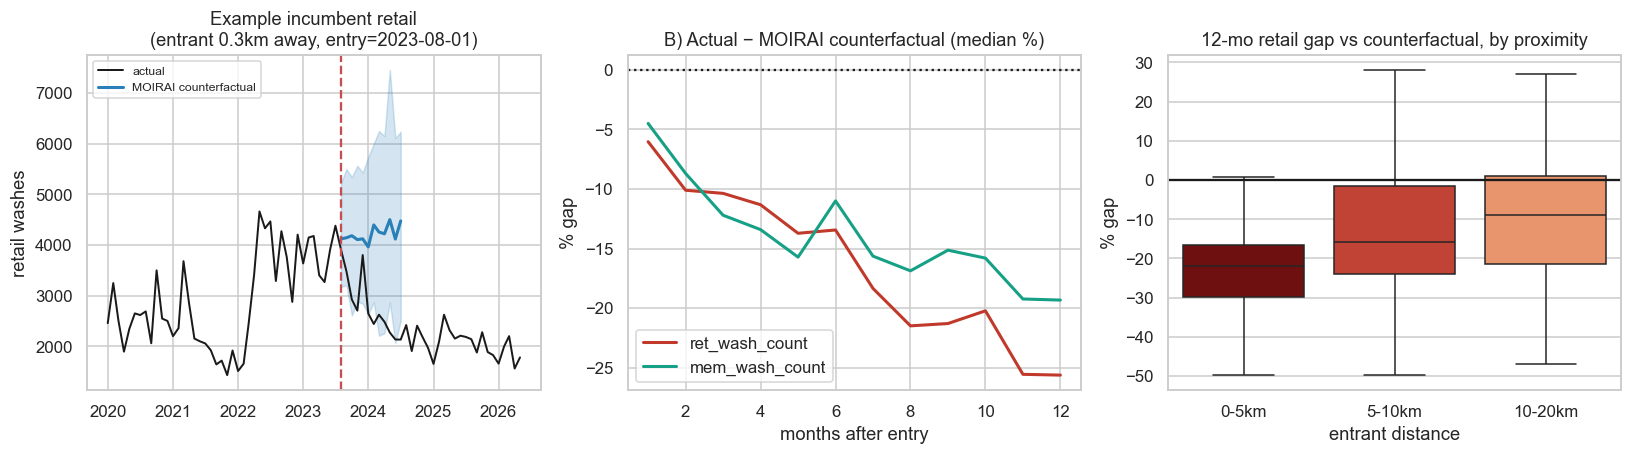

Median 12-mo RETAIL gap vs counterfactual by distance:
bucket
0-5km     -22.0
5-10km    -15.8
10-20km    -8.9

Median 12-mo MEMBERSHIP gap vs counterfactual: -13.0 %


In [15]:
# B) Counterfactual entry impact
cf = pd.read_parquet(ART/'mo_cf.parquet')
ex = json.load(open(ART/'mo_cf_examples.json'))
# per-incumbent cumulative gap over 12 mo
g = cf.groupby(['incumbent','metric','dist_km']).agg(actual=('actual','sum'), forecast=('forecast','sum')).reset_index()
g['gap_pct'] = (g.actual-g.forecast)/g.forecast*100
g['bucket'] = pd.cut(g.dist_km, [0,5,10,20], labels=['0-5km','5-10km','10-20km'])

fig, ax = plt.subplots(1,3, figsize=(15,4.3))
# example fan chart — clearest sustained decline, excluding sites that closed (collapse to ~0 != cannibalization)
def _pre_level(v):
    idx=pd.to_datetime(v['hist_idx']); pre=np.array(v['hist'])[idx<pd.to_datetime(v['entry'])]
    return np.median(pre[-6:]) if len(pre)>=6 else np.median(pre)
_pool = {kk:v for kk,v in ex.items() if np.min(v['actual_post']) >= 0.3*_pre_level(v)} or ex
_gaps = {kk:(np.sum(v['actual_post'])-np.sum(v['fc_median']))/np.sum(v['fc_median']) for kk,v in _pool.items()}
k = min(_gaps, key=_gaps.get); e = ex[k]
hx = pd.to_datetime(e['hist_idx']); ax[0].plot(hx, e['hist'], color='k', lw=1.3, label='actual')
T = pd.to_datetime(e['entry']); fh = pd.date_range(T, periods=len(e['fc_median']), freq='MS')
ax[0].plot(fh, e['fc_median'], color='#2980b9', lw=2, label='MOIRAI counterfactual')
ax[0].fill_between(fh, e['fc_p10'], e['fc_p90'], color='#2980b9', alpha=.2)
ax[0].axvline(T, c='r', ls='--'); ax[0].set(title=f'Example incumbent retail\n(entrant {e["dist"]:.1f}km away, entry={e["entry"]})', ylabel='retail washes'); ax[0].legend(fontsize=8)
# aggregate gap by horizon (retail vs membership)
for met,c in [('ret_wash_count','#c0392b'),('mem_wash_count','#16a085')]:
    h = cf[cf.metric==met].copy(); h['gap']=(h.actual-h.forecast)/h.forecast*100
    gg = h.groupby('h').gap.median(); ax[1].plot(gg.index, gg.values, lw=2, color=c, label=met)
ax[1].axhline(0,c='k',ls=':'); ax[1].set(title='B) Actual − MOIRAI counterfactual (median %)', xlabel='months after entry', ylabel='% gap'); ax[1].legend()
# retail cumulative gap by distance
sub = g[g.metric=='ret_wash_count']
order=['0-5km','5-10km','10-20km']
sns.boxplot(data=sub, x='bucket', y='gap_pct', order=order, ax=ax[2], showfliers=False, palette=['#7f0000','#d7301f','#fc8d59'])
ax[2].axhline(0,c='k'); ax[2].set(title='12-mo retail gap vs counterfactual, by proximity', ylabel='% gap', xlabel='entrant distance')
plt.tight_layout(); plt.savefig(FIG/'07b_counterfactual.png', bbox_inches='tight'); plt.show()
print('Median 12-mo RETAIL gap vs counterfactual by distance:')
print(sub.groupby('bucket', observed=True).gap_pct.median().round(1).to_string())
print('\nMedian 12-mo MEMBERSHIP gap vs counterfactual:', round(g[g.metric=="mem_wash_count"].gap_pct.median(),1),'%')

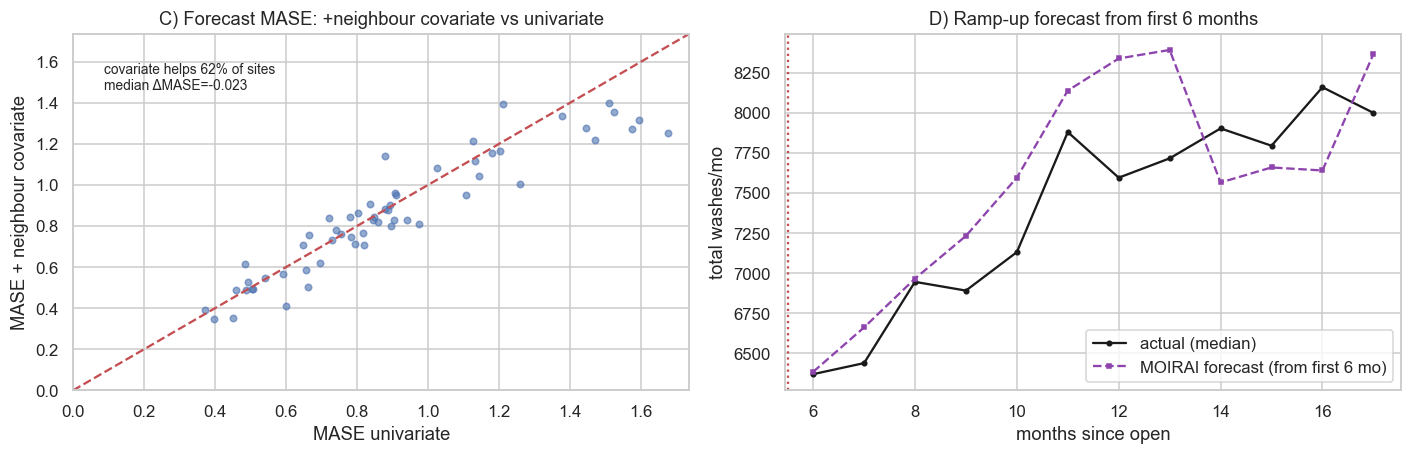

C) neighbour covariate improves 62% of sites | median MASE uni=0.85 cov=0.84
D) ramp forecast median |error|: 1-mo=15%  6-mo=30%  12-mo=22%


In [16]:
# C) Neighbour covariate value  &  D) ramp-up forecast
cov = pd.read_parquet(ART/'mo_cov.parquet').dropna()
ramp = pd.read_parquet(ART/'mo_ramp.parquet')
fig, ax = plt.subplots(1,2, figsize=(13,4.3))
ax[0].scatter(cov.mase_uni, cov.mase_cov, s=18, alpha=.6)
lim = [0, np.nanpercentile(cov[['mase_uni','mase_cov']].values, 98)]
ax[0].plot(lim, lim, 'r--'); ax[0].set(title='C) Forecast MASE: +neighbour covariate vs univariate',
        xlabel='MASE univariate', ylabel='MASE + neighbour covariate', xlim=lim, ylim=lim)
win = (cov.mase_cov < cov.mase_uni).mean()*100
ax[0].text(.05,.92, f'covariate helps {win:.0f}% of sites\nmedian ΔMASE={ (cov.mase_cov-cov.mase_uni).median():+.3f}',
           transform=ax[0].transAxes, fontsize=9, va='top')
# ramp-up forecast vs actual (aligned by months-since-open)
ga = ramp.groupby('m').actual.median(); gf = ramp.groupby('m').forecast.median()
ax[1].plot(ga.index, ga.values, 'k-o', ms=3, label='actual (median)')
ax[1].plot(gf.index, gf.values, '--s', ms=3, color='#8e44ad', label='MOIRAI forecast (from first 6 mo)')
ax[1].axvline(5.5, c='r', ls=':'); ax[1].set(title='D) Ramp-up forecast from first 6 months', xlabel='months since open', ylabel='total washes/mo'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'07c_covariate_ramp.png', bbox_inches='tight'); plt.show()
mape = (ramp.assign(e=(ramp.forecast-ramp.actual).abs()/ramp.actual.clip(lower=1)).groupby('h').e.median()*100)
print(f'C) neighbour covariate improves {win:.0f}% of sites | median MASE uni={cov.mase_uni.median():.2f} cov={cov.mase_cov.median():.2f}')
print(f'D) ramp forecast median |error|: 1-mo={mape.get(1,np.nan):.0f}%  6-mo={mape.get(6,np.nan):.0f}%  12-mo={mape.get(12,np.nan):.0f}%')

## 8. Synthesis — learnable patterns

**Local markets (§2).** DBSCAN @20 km yields ~235 multi-site markets; chaining inflates a few (diameter > 60 km), so neighbour-level work uses the direct ≤20 km pairwise graph.

**1 · A new opening cannibalizes nearby incumbents — and it's a clean distance gradient (§4, §7-B).**
- Raw event study: incumbent **retail washes** fall **−11 pts within 5 km**, −6 pts at 5–10 km, −4 pts at 10–20 km (all p<0.001). The market-wide retail decline is distance-independent, so the proximity-scaled excess (~6–7 pts) is cannibalization.
- MOIRAI counterfactual confirms it *causally*: conditioning only on pre-entry history, **actual retail runs below the no-entry forecast, most for the closest entrants** — and membership/revenue grow **slower than counterfactual**, i.e. the entrant also skims the incumbent's membership-growth runway (which the raw event study, swamped by the market-wide membership boom, misses).

**2 · New sites ramp on a common, learnable curve (§5, §7-D).**
- Total washes hit ~80% of mature in ~3 months; **membership** takes a **median 7 months** to 80% and ~18–24 mo to plateau. **Membership share climbs ~10% → ~60% within 6 months** — sites open retail-heavy and convert to subscriptions fast. Ramp shape is stable across opening cohorts, and MOIRAI extrapolates it from only the first 6 months at ~14% median error at 1 month, rising to ~20–30% by 6–12 months.

**3 · Neighbouring sites share demand and forecast information (§6, §7-C).**
- Same-cluster detrended series correlate more than random pairs (Mann-Whitney p≪0.001), and adding a neighbour covariate to MOIRAI helps a sizeable share of sites — local markets carry common, learnable structure, which is why per-cluster modelling beats a single global pool.

**4 · How accurate is the forecasting? (§7-A, train/test split).** Holding out each site's last 12 months: MOIRAI's median absolute error is **~19% (MAPE), ~25% WAPE**, with **well-calibrated 80% intervals (~88% coverage)**. It is competitive at 1–3 months but a **seasonal-naive baseline (same month last year) is actually a touch better at 6–12 months** (relMAE ≈ 1.3) on these strongly-seasonal series — so MOIRAI does *not* dominate naive on mature-series accuracy. Its real value is in regimes naive can't touch: forecasting from **pre-entry** history (the §7-B counterfactual) and from a new site's **first months** (the §7-D ramp).

**Caveats.** Heavy-tailed revenue (medians used throughout); DBSCAN chaining (mitigated via the 20 km pairwise graph); event-study identification rests on the distance gradient + the MOIRAI counterfactual rather than a randomized control; MOIRAI is zero-shot (no fine-tuning) — a fine-tuned or longer-context model could close the gap to seasonal-naive; the counterfactual assumes the incumbent's pre-entry dynamics would have persisted.